##  Vincent Mui - May 2026

### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for numeric distributions and outliers (IQRs)

In [4]:
# Inspect numeric data for distribution and outliers
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


2. Investigate the dataset for missing or problematic data.

  - 2.a  Investigate the dataset for duplicate rows
  - 2.b Investigate the dataset for incorrect data types and bad values: temperature, age, has_children, etc.
  - 2.c Investigete useless column(s)
  - 2.d Investigate the dataset for missing values
    -  Compile a list of columns with highest number of missing values on top

In [5]:
print("="*100)
print("2. DATA INVESTIGATION")
print("="*100)

# Original dataset dimensions
print("Total number of raw data rows and columns:", data.shape)
print("-"*100)

# 2.a Investigate duplicates
print("2.a Number of duplicate rows:", data.duplicated().sum())
print("-"*100)

# 2.b Inspect possible incorrect data types
print("2.b Possible incorrect data types and bad values")
# Compare temperature column data type and its values
print("  'temperature' column data type:", data.temperature.dtype, ", values:", data["temperature"].unique())
# Compare age column data type and its values
print("  'age' column data type:", data.age.dtype, ", values:", data["age"].unique())
# Compare has_children column data type and its values
print("  'has_children' column data type:", data.has_children.dtype, ", values:", data["has_children"].unique())

print("-"*100)

# 2.c Investigate useless column, after studying .describe() stats from above
print("2.c Bad Column")
print("  'toCoupon_GEQ5min' column data type:", data.toCoupon_GEQ5min.dtype, ", values:", data["toCoupon_GEQ5min"].unique())
print("-"*100)

# 2.d Investigate missing values
print("2.d Missing values")
print("  Number of missing value in each column:\n", data.isnull().sum().sort_values(ascending=False))
print("-"*100)


2. DATA INVESTIGATION
Total number of raw data rows and columns: (12684, 26)
----------------------------------------------------------------------------------------------------
2.a Number of duplicate rows: 74
----------------------------------------------------------------------------------------------------
2.b Possible incorrect data types and bad values
  'temperature' column data type: int64 , values: [55 80 30]
  'age' column data type: str , values: <StringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str
  'has_children' column data type: int64 , values: [1 0]
----------------------------------------------------------------------------------------------------
2.c Bad Column
  'toCoupon_GEQ5min' column data type: int64 , values: [1]
----------------------------------------------------------------------------------------------------
2.d Missing values
  Number of missing value in each column:
 car                     12576
CoffeeHouse        

  - 2.a Further investigate duplicate data rows
    -  Inspect duplicate rows

In [6]:
# Fetch duplidate data rows
print("="*100)
print("2.a DATA INVESTIGATION: NUMBER OF DUPLICATE DATA ROWS =", data[data.duplicated()].shape[0])
print("="*100)

# display a few for manual inspection
print(data[data.duplicated()].head(6)) 
print("-"*100)

2.a DATA INVESTIGATION: NUMBER OF DUPLICATE DATA ROWS = 74
     destination passanger weather  temperature time                 coupon  \
4192        Work     Alone   Sunny           80  7AM  Carry out & Take away   
4236        Work     Alone   Sunny           80  7AM  Carry out & Take away   
4280        Work     Alone   Sunny           80  7AM  Carry out & Take away   
4324        Work     Alone   Sunny           80  7AM  Carry out & Take away   
4409        Work     Alone   Sunny           80  7AM  Carry out & Take away   
4475        Work     Alone   Sunny           80  7AM  Carry out & Take away   

     expiration  gender age maritalStatus  ...  CoffeeHouse CarryAway  \
4192         1d    Male  26        Single  ...        never       1~3   
4236         1d    Male  26        Single  ...          gt8       gt8   
4280         1d  Female  26        Single  ...        never       4~8   
4324         1d  Female  46        Single  ...        never       4~8   
4409         1d  Femal

  - 2.d Investigate magnitude of missing "car" values
    -  The Missing Value list shows "car" column has a lot of missing values.
    -  Calculate the magnitude to investigate if proportion of missing data > 30% 
    -  i.e. meet criteria for dropping column altogether

In [7]:
# compute percentage of missing "car" values within total observations 
# (rounded to 2 decimal points)
car_missing_pct = round(data["car"].isnull().sum()/data.shape[0]*100, 2)

# check if percentage of missing data > 30% => meet criteria for dropping column
drop_car_col_boo = True if car_missing_pct > 30 else False

print("="*100)
print("2.d DATA INVESTIGATION: 'CAR' MISSING VALUES")
print("="*100)
print("Percentage of missing car values vs. total:", car_missing_pct, "%")
print("Drop car column? =", drop_car_col_boo)
print("-"*100)

2.d DATA INVESTIGATION: 'CAR' MISSING VALUES
Percentage of missing car values vs. total: 99.15 %
Drop car column? = True
----------------------------------------------------------------------------------------------------


  - 2.d Investigate magnitude of remaining columns with missing values
    -  The Missing Value list shows other columns have some missing values:
       -  CoffeeHouse:                 217 (Highest number of missing values in this list)
       -  Restaurant20To50:            189
       -  CarryAway:                   151
       -  RestaurantLessThan20:        130
       -  Bar:                         107
    -  Calculate the magnitude to investigate if proportion of missing data < 5% (random occurences)
    -  i.e. meet criteria for dropping row(s), but not whole column(s).
    -  If CoffeeHouse (highest number of missing values in this list) < 5%, then the other 4 columns will be less than 5%, too

In [8]:
# compute percentage of missing "Coffeehouse" values within total observations 
# (rounded to 2 decimal points)
CoffeeHouse_miss_pct = round(data["CoffeeHouse"].isnull().sum()/data.shape[0]*100, 2)

# check if percentage of missing data < 5% => meet criteria for dropping rows
drop_CoffeeHouse_row_boo = True if CoffeeHouse_miss_pct < 5 else False

print("="*100)
print("2.d DATA INVESTIGATION: Remaining missing values:")
print("    CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, Bar")
print("="*100)
print("Percentage of missing CoffeeHouse values vs. total:", CoffeeHouse_miss_pct, "%")
print("Drop rows for CoffeeHouse and others with number of missing values < 5%? =", drop_CoffeeHouse_row_boo)
print("-"*100)

2.d DATA INVESTIGATION: Remaining missing values:
    CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, Bar
Percentage of missing CoffeeHouse values vs. total: 1.71 %
Drop rows for CoffeeHouse and others with number of missing values < 5%? = True
----------------------------------------------------------------------------------------------------


3. Decide what to do about your missing data -- drop, replace, other...

- Decisions on Data Cleaning and Transformation after Data investigation

- 3.a Duplicate Rows:  
   - **Finding:** there are 74 duplicate rows (0.5% of the original dataset)
   - **Assessment:** these duplicate rows do not have unique named identifiers (e.g,, Driver Name in any column) therefore these could be independent driver data rows that happened to have same combination of parameter values and not duplicates of others. Dropping these “duplicate” rows may also bias the dataset.
   - **Action:** No action on tiny percentage of “duplicate” rows 

- 3.b Incorrect Data Types + Bad Data Values: 
   - **Findings:**
      - “temperature” column data type is “integer”, but my investigation shows the column has only 3 unique values: 30, 55, 80. 
      - “age” column data type is “string”, but normally a number is expected. My investigation shows “age” had "bad" data values such as '50plus', and 'below21'
      - "passanger" column name is a typo. It should be "passenger" 
      - “has_children” has valid integer values 1 and 0.
   - **Assessment:** 
      - “temperature” data is considered “categorical” instead of continuously numeric, but since values are consistently numeric, there is no need to transform to strings 
      - “age” data has non-numeric string values such as '50plus', and 'below21', and these values represent ranges that are difficult to replace with mean, mode or median age values
   - **Action:**
      - No transformation required for “temperature” column to character strings
      - Transform the “age” column to numeric, replacing '50plus' with 50, and ‘below21’ with 20
      - Replace "passanger" column name with "passenger" 
      - No transformation required for other columns such as “has_children”


- 3.c Bad Column(s):
   - **Findings:**
      - "toCoupon_GEQ5min" column has data values = 1 only, from .describe() statistics. Therefore this column is not useful for data or trend analysis. 
      - "direction_same" column and "direction_opp" column are mutually exclusive
   - **Assessment:** 
      - Drivers were always more than 5 mins away from coupon use locations. 
      - Drivers are either driving "same" or "opp" direction, therefore do not need 2 seperate columns (redundant))
   - **Actions:**
      - It may be a good idea to merge this column with other 2 columns "toCoupon_GEQ15min", "toCoupon_GEQ25min", if mutually exclusive (either "5mins < time < 15mins", "15mins =< time < 25mins" or "time >= 25mins"). 
      - It may be a good idea to merge "direction_same" column and "direction_opp" column, into a single "direction" column with values either "same" or "opp".
      - But NO merge transformations for now, because I am not using these columns for data analysis for this round.

- 3.d Missing Values
   - **Findings:**
      - "car" column has a lot of missing values. Proportion of missing data is 99.15%,
      - Other remaining columns with missing values have proportions 1.71% or lower
   - **Assessment:** 
      - "car" column: almost all data (99.15%) is missing! And proportion is way greater than 30% threshold for dropping the column altogether
      - Other remaining columns with missing values: proportions 1.71% or lower, which meet the < 5% criteria as “random occurrences” for dropping row(s), but not whole column(s).
   - **Actions:**
      - Drop whole data column for “car”
      - Drop rows with missing values for columns CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, and Bar

- 3.e Other Considerations
   - Outliers:
The original dataset has mainly categorical columns. It does not have columns with a large distribution of numeric values for applying IQR rules to detect outliers, or to replace missing numerical values with median or mean values
   - Unwanted spaces:  
Upon visual inspection of some data rows, there is no need to trim leading and trailing spaces of values in the original datasets. 
   - Inconsistent strings: 
Upon visual inspection of some data rows, no ‘funny’ or inconsistent values were detected.


3. Continued from decisions above >> Data Preparation: Perform data transformation and cleaning

In [9]:
# Make a copy of original data before data transformation and cleaning
clean_data = data.copy()

In [10]:
## DATA TRANSFORMATION for:
## 3.b Incorrect Data Types and Bad Values

# Transform the “age” column from string to numeric
# First map "age" string values: '50plus' with '50', and ‘below21’ with '20' 
age_mapping = {'50plus':'50', 'below21':'20'}
# Replace "age" values using mapping
clean_data['age'] = clean_data['age'].replace(age_mapping)
# Then convert "age" string values to numeric values
clean_data['age'] = pd.to_numeric(clean_data['age'])

# Replace "passanger" column name typo with "passenger" 
clean_data.rename(columns={"passanger":"passenger"}, inplace=True)

In [11]:
## DATA CLEANING for:
## 3.d Missing Values

# Drop whole data column for “car”
clean_data.drop(columns=["car"], inplace=True)

# Drop rows (not columns) with missing values for remaining columns CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, and Bar
clean_data.dropna(subset=["CoffeeHouse", "Restaurant20To50", "CarryAway", "RestaurantLessThan20", "Bar"], inplace=True)

In [12]:
## Data Transformation + Cleaning Audit

print("="*100)
print("3. PREPARATION: DATA CLEANING AND TRANSFORMATION AUDIT")
print("="*100)
print("Total number of original data rows and columns:", data.shape)
print("Total number after cleaning - rows and columns:", clean_data.shape)
print("-"*100)
print("Transformed age values (numeric):", clean_data["age"].unique())
print("-"*100)
print("Corrected column name, and number of missing value in each column (descending order):\n", clean_data.isnull().sum().sort_values(ascending=False))
print(clean_data.info())
print("="*100)

3. PREPARATION: DATA CLEANING AND TRANSFORMATION AUDIT
Total number of original data rows and columns: (12684, 26)
Total number after cleaning - rows and columns: (12079, 25)
----------------------------------------------------------------------------------------------------
Transformed age values (numeric): [21 46 26 31 41 50 36 20]
----------------------------------------------------------------------------------------------------
Corrected column name, and number of missing value in each column (descending order):
 destination             0
passenger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaura

4. What proportion of the total observations chose to accept the coupon?



In [13]:
# Compute count and percentage that accepts coupon
accept_coupon_cnt = (clean_data["Y"] == 1).sum()
accept_coupon_pct = round(accept_coupon_cnt/clean_data.shape[0]*100, 2)

print("="*100)
print("PROPORTION CHOSE TO ACCEPT COUPON")
print("="*100)
print("Number of total obesrvations after data cleaning:    ", clean_data.shape[0])
print("Number of obesrvations chose to accept the coupon:   ", accept_coupon_cnt)
print("Propotion of obesrvations chose to accept the coupon:", accept_coupon_pct, "%")
print("-"*100)

PROPORTION CHOSE TO ACCEPT COUPON
Number of total obesrvations after data cleaning:     12079
Number of obesrvations chose to accept the coupon:    6877
Propotion of obesrvations chose to accept the coupon: 56.93 %
----------------------------------------------------------------------------------------------------


4. Answer:
-  57% of all drivers will accept coupons ‘right away’ or ‘later before the coupon expires’

5. Use a bar plot to visualize the `coupon` column.

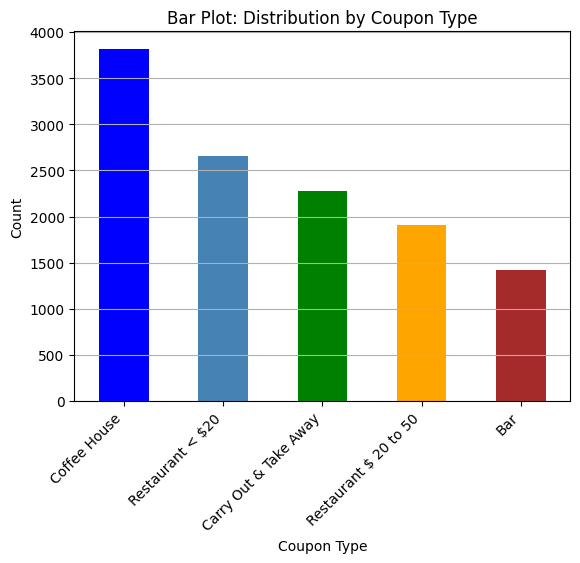

<Figure size 640x480 with 0 Axes>

In [21]:
## bar chart of coupon column: occurence count's distritbution
plt_bar_coupon = clean_data["coupon"].value_counts().plot(kind="bar", color=['blue', 'steelblue', 'green', 'orange', 'brown'])

# Insert '$' into x-axis labels for readability
plt_bar_coupon.set_xticklabels(['Coffee House', 'Restaurant < $20', 'Carry Out & Take Away', 'Restaurant $ 20 to 50', 'Bar'])
plt.title("Bar Plot: Distribution by Coupon Type")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Coupon Type")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()
plt.savefig('images/coupon_bar_plot.png')

Bar plot Interpretation:
- "Coffee House" is the most frequent coupon type in the dataset. 
- This is probably because drivers like the fast and low-price nature of coffee house offerings

6. Use a histogram to visualize the temperature column.

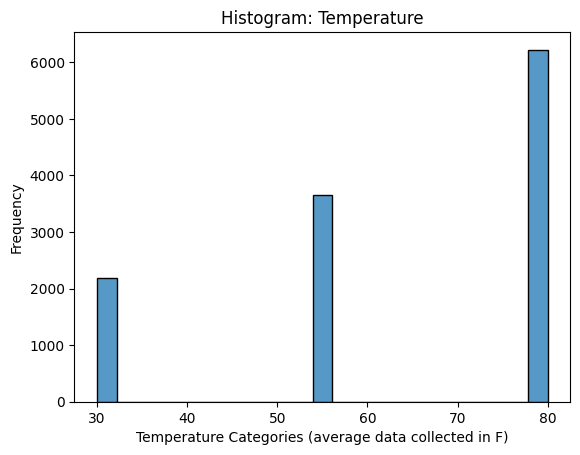

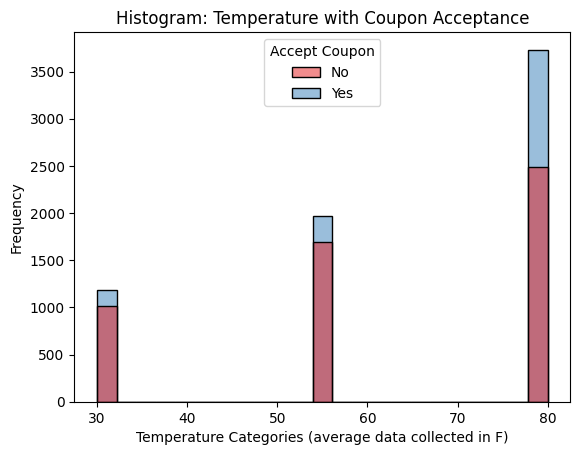

<Figure size 640x480 with 0 Axes>

In [22]:
## Histogram of temperature column
plt_hist_temp = sns.histplot(data=clean_data, x="temperature")
plt.title("Histogram: Temperature")
plt.ylabel("Frequency")
plt.xlabel("Temperature Categories (average data collected in F)")
plt.show()
plt.savefig('images/temp_hist_plot.png')

## Histogram of temperature column, with stacked coupon acceptance, for additional insights
plt_hist_temp_Y = sns.histplot(data=clean_data, x="temperature", hue="Y", palette='Set1')
sns.move_legend(plt_hist_temp_Y, loc="upper center", labels=["No", "Yes"], title="Accept Coupon")
plt.title("Histogram: Temperature with Coupon Acceptance")
plt.ylabel("Frequency")
plt.xlabel("Temperature Categories (average data collected in F)")
plt.show()
plt.savefig('images/temp_Y_hist_plot.png')

Histograms' Interpretation:
- "Temperature" data is "categorical" in nature, as pointed out in the previous DATA INVESTIGATION section. 
-  Values are 30, 50, 80. These are average values in each of the 3 temperature categories, as noted in the original description of the dataset
- Most of the data points are collected when average temperature was 80F
- And from the 2nd histogram, it seems the coupon acceptance rate is higher when temperature was higher (in the 80F group)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [17]:
# New dataframe containing only "bar coupon" data
bar_coupons_df = clean_data.loc[clean_data["coupon"] == "Bar"]


2. What proportion of bar coupons were accepted?


In [23]:
accept_bar_coupon_cnt = (bar_coupons_df["Y"] == 1).sum()
accept_bar_coupon_pct = round(accept_bar_coupon_cnt/bar_coupons_df.shape[0]*100, 2)

print("="*100)
print("2. PROPORTION CHOSE TO ACCEPT BAR COUPONS")
print("="*100)
print("Number of obesrvations chose to accept bar coupons:    ", accept_bar_coupon_cnt)
print("Number of total obesrvations for bar coupons:          ", bar_coupons_df.shape[0])
print("Proportion of obesrvations chose to accept bar coupons: ", accept_bar_coupon_pct, "%")
print("-"*100)


2. PROPORTION CHOSE TO ACCEPT BAR COUPONS
Number of obesrvations chose to accept bar coupons:     788
Number of total obesrvations for bar coupons:           1913
Proportion of obesrvations chose to accept bar coupons:  41.19 %
----------------------------------------------------------------------------------------------------


2. Answer:
-  41% of **bar coupons** were accepted ‘right away’ or ‘later before the coupon expires’
-  Bar coupons acceptance rate is less than the overall coupon acceptance rate (57%)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [24]:
# New dataframe of bar coupon data with bar visits per month = 3 or less, including never
bar_coupon_le3_df = bar_coupons_df[bar_coupons_df["Bar"].isin(['never', 'less1', '1~3'])]

# Compute count and percentage that accepts coupon with 3 or less bar visits per month
accept_bar_coupon_le3_cnt = (bar_coupon_le3_df["Y"] == 1).sum()
accept_bar_coupon_le3_pct = round(accept_bar_coupon_le3_cnt/bar_coupon_le3_df.shape[0]*100, 2)

# New dataframe of bar coupon data with bar visits more than 3 times a month
bar_coupon_gt3_df = bar_coupons_df[bar_coupons_df["Bar"].isin(['4~8', 'gt8'])]

# Compute count and percentage that accepts coupon with more than 3 bar visits a month
accept_bar_coupon_gt3_cnt = (bar_coupon_gt3_df["Y"] == 1).sum()
accept_bar_coupon_gt3_pct = round(accept_bar_coupon_gt3_cnt/bar_coupon_gt3_df.shape[0]*100, 2)

print("="*100)
print("3. Bar Coupon Acceptance Rates For:")
print(f"   Drivers who went to a bar 3 or fewer times a month  = {accept_bar_coupon_le3_pct}% \
      ({accept_bar_coupon_le3_cnt} out of {bar_coupon_le3_df.shape[0]})")
print(f"   Drivers who went to a bar more than 3 times a month = {accept_bar_coupon_gt3_pct}% \
      ({accept_bar_coupon_gt3_cnt} out of {bar_coupon_gt3_df.shape[0]})")
print("="*100)

3. Bar Coupon Acceptance Rates For:
   Drivers who went to a bar 3 or fewer times a month  = 37.27%       (641 out of 1720)
   Drivers who went to a bar more than 3 times a month = 76.17%       (147 out of 193)


3. Bar Coupon Acceptance Rates Interpretation: 
-  Drivers who went to a bar more than 3 times a month have a high bar coupon acceptance rate (76%), better than overall acceptance rate (41%), and more than double that of drivers who went to a bar 3 or fewer times (37%).
-  This is true despite the fact that the dataset have way more Drivers who went to a bar 3 or fewer times a month than more (1,720 vs 193)
-  It is logical that drivers who love going to bars frequently are more likely to accept bar coupons.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [25]:
# New dataframe of bar coupon data with bar visits > 1, and age over 25
bar_coupons_df4 = bar_coupons_df[bar_coupons_df["Bar"].isin(['1~3', '4~8', 'gt8']) & (bar_coupons_df["age"] > 25)]

# Compute count and percentage that accepts coupon in this subset
accept_bar_coupon_df4_cnt = (bar_coupons_df4["Y"] == 1).sum()
accept_bar_coupon_df4_pct = round(accept_bar_coupon_df4_cnt/bar_coupons_df4.shape[0]*100, 2)

# New dataframe of bar coupon data for all the others outside of above subset (i.e. exclude the above df4 rows)
bar_others_df4 = bar_coupons_df.drop(index=bar_coupons_df4.index)

# Compute count and percentage that accepts coupon for all others
accept_bar_others_df4_cnt = (bar_others_df4["Y"] == 1).sum()
accept_bar_others_df4_pct = round(accept_bar_others_df4_cnt/bar_others_df4.shape[0]*100, 2)

print("="*100)
print("4. Bar Coupon Acceptance Rates For:")
print(f"   Drivers who go to a bar more than once a month and over age 25 = {accept_bar_coupon_df4_pct}% \
      ({accept_bar_coupon_df4_cnt} out of {bar_coupons_df4.shape[0]})")
print(f"   All the other drivers                                          = {accept_bar_others_df4_pct}% \
      ({accept_bar_others_df4_cnt} out of {bar_others_df4.shape[0]})")
print("="*100)


4. Bar Coupon Acceptance Rates For:
   Drivers who go to a bar more than once a month and over age 25 = 68.98%       (278 out of 403)
   All the other drivers                                          = 33.77%       (510 out of 1510)


4. Bar Coupon Acceptance Rates Interpretation: 
-  Drivers over age 25 who went to a bar more than once a month have a high bar coupon acceptance rate (69%), better than overall acceptance rate (41%), and more than double that of other drivers (34%).
-  This is true despite the fact that the dataset have way more Drivers in the "other" category (1,510 vs 403)
-  It is logical that adult drivers who love going to bars frequently are more likely to accept bar coupons.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [26]:
# New dataframe of bar coupon data with bar visits > 1, had passengers that were not a kid 
#     and had occupations other than farming, fishing, or forestry.
bar_coupons_df5 = bar_coupons_df[bar_coupons_df["Bar"].isin(['1~3', '4~8', 'gt8']) &
                                ~(bar_coupons_df["passenger"] == "Kid(s)") &
                                ~(bar_coupons_df["occupation"] == "Farming Fishing & Forestry")]

# Compute count and percentage that accepts coupon in this subset
accept_bar_coupon_df5_cnt = (bar_coupons_df5["Y"] == 1).sum()
accept_bar_coupon_df5_pct = round(accept_bar_coupon_df5_cnt/bar_coupons_df5.shape[0]*100, 2)

# New dataframe of bar coupon data for all the others outside of above subset (i.e. exclude the above df5 rows)
bar_others_df5 = bar_coupons_df.drop(index=bar_coupons_df5.index)

# Compute count and percentage that accepts coupon for all others
accept_bar_others_df5_cnt = (bar_others_df5["Y"] == 1).sum()
accept_bar_others_df5_pct = round(accept_bar_others_df5_cnt/bar_others_df5.shape[0]*100, 2)

print("="*100)
print("5. Bar Coupon Acceptance Rates For:")
print(f"   (A) Drivers who go to a bar more than once a month and had passengers that were not a kid and \n \
      had occupations other than farming, fishing, or forestry = {accept_bar_coupon_df5_pct}% \
      ({accept_bar_coupon_df5_cnt} out of {bar_coupons_df5.shape[0]})"
      )
print(f"   (B) All the other drivers                                    = {accept_bar_others_df5_pct}% \
      ({accept_bar_others_df5_cnt} out of {bar_others_df5.shape[0]})"
      )
print("="*100)


5. Bar Coupon Acceptance Rates For:
   (A) Drivers who go to a bar more than once a month and had passengers that were not a kid and 
       had occupations other than farming, fishing, or forestry = 70.94%       (376 out of 530)
   (B) All the other drivers                                    = 29.79%       (412 out of 1383)


5. Bar Coupon Acceptance Rates Interpretation: 
-  Drivers who went to a bar more than once a month, not driving a kid, not in farming, fishing, or forestry have a high bar coupon acceptance rate (71%), better than overall acceptance rate (41%), and more than double that of other drivers (30%).
-  This is true despite the fact that the dataset have way more Drivers in the "other" category (1,383 vs 530)
-  It is logical that drivers who love going to bars frequently but driving a kid were less likely to accept bar coupons (kids are not allowed to go to bar to drink alcohol) 
-  It is interesting to learn that occupations not in farming, fishing, or forestry played a role in bar coupon acceptance. This may be due to these occupations are usually in remote locations with fewer bar selections

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [27]:
# Examine the "income" data for different value selections in filter use
print(data["income"].unique())

<StringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$12500 - $24999',
  '$75000 - $87499',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']
Length: 9, dtype: str


In [28]:
# Set up filter conditions for each sub group:

# 1. went to bars more than once a month, had passengers that were not a kid, and were not widowed
filter1 = (bar_coupons_df["Bar"].isin(['1~3', '4~8', 'gt8']) & 
            ~(bar_coupons_df["passenger"] == "Kid(s)") & 
            ~(bar_coupons_df["maritalStatus"] == "Widowed"))

# 2. went to bars more than once a month and are under the age of 30
filter2 = (bar_coupons_df["Bar"].isin(['1~3', '4~8', 'gt8']) & 
            (bar_coupons_df["age"] < 30))

# 3. went to cheap restaurants more than 4 times a month and income is less than 50K
filter3 = (bar_coupons_df["RestaurantLessThan20"].isin(['4~8', 'gt8']) &
            bar_coupons_df["income"].isin(['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']))

# New dataframe of bar coupon data by combining all 3 filter conditions with 'OR' operators
combined_df6 = bar_coupons_df[ filter1 | filter2 | filter3 ]

# Compute count and percentage that accepts coupon in this combined set
accept_bar_df6_cnt = (combined_df6["Y"] == 1).sum()
accept_bar_df6_pct = round(accept_bar_df6_cnt/combined_df6.shape[0]*100, 2)

# New dataframe of bar coupon data for all the others outside of above combined set (i.e. exclude the above df6 rows)
bar_others_df6 = bar_coupons_df.drop(index=combined_df6.index)

# Compute count and percentage that accepts coupon for all others
accept_bar_others_df6_cnt = (bar_others_df6["Y"] == 1).sum()
accept_bar_others_df6_pct = round(accept_bar_others_df6_cnt/bar_others_df6.shape[0]*100, 2)

print("="*120)
print("6. Bar Coupon Acceptance Rates For Drivers Who:")
print(f"   (A) went to bars more than once a month, had passengers that were not a kid, and were not widowed *OR* \n \
      went to bars more than once a month and are under the age of 30 *OR* \n \
      went to cheap restaurants more than 4 times a month and income is less than 50K  = {accept_bar_df6_pct}% \
      ({accept_bar_df6_cnt} out of {combined_df6.shape[0]})"
      )
print(f"   (B) All the other drivers                                                            = {accept_bar_others_df6_pct}% \
      ({accept_bar_others_df6_cnt} out of {bar_others_df6.shape[0]})"
      )
print("="*120)


6. Bar Coupon Acceptance Rates For Drivers Who:
   (A) went to bars more than once a month, had passengers that were not a kid, and were not widowed *OR* 
       went to bars more than once a month and are under the age of 30 *OR* 
       went to cheap restaurants more than 4 times a month and income is less than 50K  = 58.71%       (438 out of 746)
   (B) All the other drivers                                                            = 29.99%       (350 out of 1167)


6. Bar Coupon Acceptance Rates Interpretation: 
-  Drivers who fullfill the 3 specified conditions have a high bar coupon acceptance rate (59%), better than overall acceptance rate (41%), and almost double that of other drivers (30%).
-  It is logical that widowed drivers who love going to bars frequently but driving a kid were *less* likely to accept bar coupons (kids are not allowed to go to bar to drink alcohol) 
-  It is interesting to learn that drivers under age 30 who love going to bars frequently are also likely to accept bar coupons.
-  It is logical that drivers who went to cheap restaurants frequenly with lower income are cost-conscious, therefore more likely to accept bar coupons to save money.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Summary
- Bar coupons acceptance rate (41%) is less than the overall coupon acceptance rate (57%). i.e. over half of the driver population did not accept the car coupon. 
  - Hypothesis: drivers are mindful that “don’t drink and drive”.

- Drivers who went to a bar more than 3 times a month have a high bar coupon acceptance rate (76%), more than double that of drivers who went to a bar 3 or fewer times (37%).
- Adult drivers (age over 25) who love going to bars frequently are more likely to accept bar coupons (69%).
  - Hypothesis: drivers who are frequent bar goers are more likely to accept bar coupons

- Drivers who went to a bar more than once a month, not driving a kid, not in farming, fishing, or forestry have a high bar coupon acceptance rate (71%), more than double that of other drivers (30%). 
  - Hypothesis: these three occupations are usually in remote locations with fewer bar selections

- Widowed Drivers who love going to bars frequently but driving a kid were less likely to accept bar coupons. 
  - Hypothesis: under-age kids are not allowed in bars to consume alcohol.

- Drivers who went to cheap restaurants frequently with lower incomes are more likely to accept bar coupons. 
  - Hypothesis: this group are cost-conscious and love coupons to save money.



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Since the previous Bar plot revealed "Coffee House" is the most frequent coupon group in the dataset, I am going to explore this coupon group.
1. To investigate the Coffee House Coupons, I will first create a new `DataFrame` that contains just the Coffee House coupons.

In [29]:
# New dataframe containing only "coffee house coupon" data
coffee_df = clean_data.loc[clean_data["coupon"] == "Coffee House"]

2. Investigate what proportion of coffee house coupons were accepted

In [30]:
accept_coffee_cnt = (coffee_df["Y"] == 1).sum()
accept_coffee_pct = round(accept_coffee_cnt/coffee_df.shape[0]*100, 2)

print("="*100)
print("2. PROPORTION CHOSE TO ACCEPT COFFEE HOUSE COUPONS")
print("="*100)
print("Number of obesrvations chose to accept coffee house coupons:    ", accept_coffee_cnt)
print("Number of total obesrvations for coffee house coupons:          ", coffee_df.shape[0])
print("Proportion of obesrvations chose to accept coffee house coupons: ", accept_coffee_pct, "%")
print("-"*100)

2. PROPORTION CHOSE TO ACCEPT COFFEE HOUSE COUPONS
Number of obesrvations chose to accept coffee house coupons:     1894
Number of total obesrvations for coffee house coupons:           3816
Proportion of obesrvations chose to accept coffee house coupons:  49.63 %
----------------------------------------------------------------------------------------------------


2. Observations:
-  50% of **coffee house coupons** were accepted ‘right away’ or ‘later before the coupon expires’
-  Coffee house coupons acceptance rate is less than the overall coupon acceptance rate (57%)
-  But coffee house coupons acceptance rate is higher than bar coupon acceptance rate (41%)

3. Compare the acceptance rate between those who went to a coffee house 3 or fewer times a month to those who went more.

In [31]:
# New dataframe of coffee house coupon data with bar visits per month = 3 or less, including never
coffee_le3_df = coffee_df[coffee_df["CoffeeHouse"].isin(['never', 'less1', '1~3'])]

# Compute count and percentage that accepts coupon with 3 or less coffee house visits per month
accept_coffee_le3_cnt = (coffee_le3_df["Y"] == 1).sum()
accept_coffee_le3_pct = round(accept_coffee_le3_cnt/coffee_le3_df.shape[0]*100, 2)

# New dataframe of coffee house coupon data with coffee house visits more than 3 times a month
coffee_gt3_df = coffee_df[coffee_df["CoffeeHouse"].isin(['4~8', 'gt8'])]

# Compute count and percentage that accepts coupon with more than 3 coffee house visits a month
accept_coffee_gt3_cnt = (coffee_gt3_df["Y"] == 1).sum()
accept_coffee_gt3_pct = round(accept_coffee_gt3_cnt/coffee_gt3_df.shape[0]*100, 2)

print("="*100)
print("3. Coffee House Coupon Acceptance Rates For:")
print(f"   Drivers who went to a coffee house 3 or fewer times a month  = {accept_coffee_le3_pct}% \
      ({accept_coffee_le3_cnt} out of {coffee_le3_df.shape[0]})")
print(f"   Drivers who went to a coffee house more than 3 times a month = {accept_coffee_gt3_pct}% \
      ({accept_coffee_gt3_cnt} out of {coffee_gt3_df.shape[0]})")
print("="*100)

3. Coffee House Coupon Acceptance Rates For:
   Drivers who went to a coffee house 3 or fewer times a month  = 44.59%       (1323 out of 2967)
   Drivers who went to a coffee house more than 3 times a month = 67.26%       (571 out of 849)


3. Coffee House Coupon Acceptance Rates Interpretation: 
-  Drivers who went to a coffee house more than 3 times a month have a high coffee house coupon acceptance rate (67%), better than overall acceptance rate (50%), and more than that of drivers who went 3 or fewer times (45%).
-  This is true despite the fact that the dataset have way more Drivers who went to a coffee house 3 or fewer times a month than more (2,976 vs 849)
-  It is logical that drivers who love going to coffee houses frequently are more likely to accept coffee house coupons.

4. Compare the acceptance rate between drivers who go to a coffee house more than 3 times a month and driving with passenger(s) to the all others.  

In [32]:
# New dataframe of coffee house coupon data with coffee house visits > 3, and not driving alone
coffee_df4 = coffee_df[coffee_df["CoffeeHouse"].isin(['4~8', 'gt8']) & ~(coffee_df["passenger"] == "Alone")]

# Compute count and percentage that accepts coupon in this subset
accept_coffee_df4_cnt = (coffee_df4["Y"] == 1).sum()
accept_coffee_df4_pct = round(accept_coffee_df4_cnt/coffee_df4.shape[0]*100, 2)

# New dataframe of coffee house coupon data for all the others outside of above subset (i.e. exclude the above df4 rows)
coffee_others_df4 = coffee_df.drop(index=coffee_df4.index)

# Compute count and percentage that accepts coupon for all others
coffee_others_df4_cnt = (coffee_others_df4["Y"] == 1).sum()
coffee_others_df4_pct = round(coffee_others_df4_cnt/coffee_others_df4.shape[0]*100, 2)

print("="*105)
print("4. Coffee House Coupon Acceptance Rates For:")
print(f"   Drivers who go to a coffee house > 3 times a month with passenger(s) = {accept_coffee_df4_pct}% \
      ({accept_coffee_df4_cnt} out of {coffee_df4.shape[0]})")
print(f"   All the other drivers                                                = {coffee_others_df4_pct}% \
     ({coffee_others_df4_cnt} out of {coffee_others_df4.shape[0]})")
print("="*105)


4. Coffee House Coupon Acceptance Rates For:
   Drivers who go to a coffee house > 3 times a month with passenger(s) = 74.64%       (256 out of 343)
   All the other drivers                                                = 47.16%      (1638 out of 3473)


4. Coffee House Acceptance Rates Interpretation: 
-  Drivers with passenger(s) who went to a coffee house more than 3 times a month have a high coffee house coupon acceptance rate (75%), better than overall acceptance rate (50%).
-  This is true despite the fact that the dataset have way more drivers in the "other" category (3,473 vs 343)
-  Therefore drivers who are driving with passenger(s) who love going to coffee houses are more likely to accept coffee house coupons

5. Compare the Coffee House Coupon acceptance rates between frequent coffee house visitors who drove in same direction vs. in opposite direction as destination

In [33]:
# New dataframe of coffee house coupon data for frequent coffee house visitors with driving direction same as destination
coffee_same_df5 = coffee_df[coffee_df["CoffeeHouse"].isin(['4~8', 'gt8']) & (coffee_df["direction_same"] == 1)]

# Compute count and percentage that accepts coupon in this subset
accept_same_df5_cnt = (coffee_same_df5["Y"] == 1).sum()
accept_same_df5_pct = round(accept_same_df5_cnt/coffee_same_df5.shape[0]*100, 2)

# New dataframe of coffee house coupon data for frequent coffee house visitors with driving direction opposite of destination
coffee_opp_df5 = coffee_df[coffee_df["CoffeeHouse"].isin(['4~8', 'gt8']) & (coffee_df["direction_opp"] == 1)]

# Compute count and percentage that accepts coupon in this subset
accept_opp_df5_cnt = (coffee_opp_df5["Y"] == 1).sum()
accept_opp_df5_pct = round(accept_opp_df5_cnt/coffee_opp_df5.shape[0]*100, 2)

print("="*115)
print("5. Coffee House Coupon Acceptance Rates For:")
print(f"   Frequent coffee house visitors with driving direction same as destination     = {accept_same_df5_pct}% \
      ({accept_same_df5_cnt} out of {coffee_same_df5.shape[0]})")
print(f"   Frequent coffee house visitors with driving direction opposite to destination = {accept_opp_df5_pct}% \
     ({accept_opp_df5_cnt} out of {coffee_opp_df5.shape[0]})")
print("="*115)


5. Coffee House Coupon Acceptance Rates For:
   Frequent coffee house visitors with driving direction same as destination     = 76.16%       (131 out of 172)
   Frequent coffee house visitors with driving direction opposite to destination = 64.99%      (440 out of 677)


5. Coffee House Acceptance Rates Interpretation: 
-  Drivers who went to a coffee house more than 3 times a month have a high coffee house coupon acceptance rate regardless of direction of driving (same or opposite to destination). 
-  Driving direction is not a predictive indicator of coupon acceptance; these frequent coffee house visitors are likely to accept the coffee house coupons anyway!

6. Compare the acceptance rates between those drivers who:

- drove when weather is rainy and during morning hours (7AM to 10AM) *OR*
- were students and drove when temperature was above 60F *OR*
- went to coffee houses more than 3 times a month, had passengers that were kids, and were not widowed 

In [34]:
# Set up filter conditions for each sub group:

# 1. drove when weather is rainy and during morning hours (7AM to 10AM)
filter4 = ((coffee_df["weather"] == "Rainy") & 
            coffee_df["time"].isin(['7AM', '10AM']))

# 2. drove when temperature was higher than 60F and were students
filter5 = ((coffee_df["temperature"] > 60) &
            (coffee_df["occupation"] == "Student"))

# 3. went to coffee houses more than 3 times a month, had passengers that were kids, and were not widowed
filter6 = (coffee_df["CoffeeHouse"].isin(['4~8', 'gt8']) & 
            (coffee_df["passenger"] == "Kid(s)") & 
            ~(coffee_df["maritalStatus"] == "Widowed"))

# New dataframe of coffee house coupon data by combining all 3 filter conditions with 'OR' operators
coffee_df6 = coffee_df[ filter4 | filter5 | filter6 ]

# Compute count and percentage that accepts coupon in this combined set
accept_coffee_df6_cnt = (coffee_df6["Y"] == 1).sum()
accept_coffee_df6_pct = round(accept_coffee_df6_cnt/coffee_df6.shape[0]*100, 2)

# New dataframe of bar coupon data for all the others outside of above combined set (i.e. exclude the above df6 rows)
coffee_others_df6 = coffee_df.drop(index=coffee_df6.index)

# Compute count and percentage that accepts coupon for all others
coffee_others_df6_cnt = (coffee_others_df6["Y"] == 1).sum()
coffee_others_df6_pct = round(coffee_others_df6_cnt/coffee_others_df6.shape[0]*100, 2)

print("="*130)
print("6. Coffee House Coupon Acceptance Rates For Drivers Who:")
print(f"   (A) drove when weather is rainy and during morning hours (7AM to 10AM) *OR* \n \
      were students and drove when temperature was above 60F *OR* \n \
      went to coffee houses more than 3 times a month, had kids as passengers, and not widowed = {accept_coffee_df6_pct}% \
      ({accept_coffee_df6_cnt} out of {coffee_df6.shape[0]})"
      )
print(f"   (B) All the other drivers                                                                    = {coffee_others_df6_pct}% \
      ({coffee_others_df6_cnt} out of {coffee_others_df6.shape[0]})"
      )
print("="*130)


6. Coffee House Coupon Acceptance Rates For Drivers Who:
   (A) drove when weather is rainy and during morning hours (7AM to 10AM) *OR* 
       were students and drove when temperature was above 60F *OR* 
       went to coffee houses more than 3 times a month, had kids as passengers, and not widowed = 63.83%       (270 out of 423)
   (B) All the other drivers                                                                    = 47.86%       (1624 out of 3393)


6. Coffee House Coupon Acceptance Rates Interpretation: 
-  Drivers who fulfill the 3 specified conditions have a high coffee house coupon acceptance rate (64%), better than overall acceptance rate (50%).
-  It is logical that drivers liked coffee house coupons during morning time (when most people needed coffees), especially hot coffees when it was rainy outside!
-  It is interesting to learn that student drivers were more likely to accept coffee house coupons when temperature was hot outside - maybe to do school work with air conditioning inside a coffee house.
-  It is logical that drivers who visited coffee houses frequently were likely to accept coffee house coupons even with kids inside the car!

7.  Based on these observations, below are my hypothesis about drivers who accepted the coffee house coupons.

Summary
- Coffee house coupons acceptance rate (50%) is less than the overall coupon acceptance rate (57%). But coffee house coupons acceptance rate is still higher than bar coupon acceptance rate (41%)
- Drivers who went to coffee houses more than 3 times a month have a higher coffee house coupon acceptance rate (67%), than that of drivers who went 3 or fewer times (45%). 
  - Hypothesis: drivers who are already frequent coffee shop visitors tend to accept coffee house coupons.
- Drivers with passenger(s), who went to a coffee house more than 3 times a month have a high coffee house coupon acceptance rate (75%) than the other drivers. 
  - Hypothesis: coffee lovers would love to drive passengers to use coupons to enjoy coffees together.
- Driving direction is not a predictive indicator of coupon acceptance. 
  - Hypothesis: these frequent coffee shop visitors love coffees so much that they will accept the coffee house coupons anyway, regardless of driving direction!
- Drivers liked coffee house coupons during morning time, when it was rainy outside. 
  - Hypothesis: mornings are when most people needed coffee, especially when coffee houses are good shelters in rainy days.
- Student drivers were more likely to accept coffee house coupons when temperature was hot outside. 
  - Hypothesis: students like to do schoolwork with air conditioning inside a coffee house.




Recommendations
- Both bar and coffee house coupon groups show that when drivers were already frequent visitors of that coupon category, they displayed higher coupon acceptance rates for that category.  Therefore, it is highly recommended to target promotion of coupons to those who are already frequent visitors.
- Coffee house coupons are popular and more likely to be accepted. Bar coupons are not very popular overall, especially when passengers are kids. It will be more effective to promote popular coffee house coupons than bar coupons.
- Driver’s occupation plays a role in coupon acceptance. It is more effective to promote bar coupons to drivers that do not have occupations in remote areas. And it is more effective to promote coffee house coupons to students when outside temperature is hot.
- Time of the day, weather and temperature play a role in coffee house coupon acceptance. It is more effective to send drivers coffee house coupons in rainy mornings!
- Spending level affects coupon acceptance. Bar coupon issuers should target drivers who go to cheap restaurants frequently with lower income level.

Next Step
- In addition to the recommendations above, it is logical to continue to examine all the other coupon groups (restaurants, takeouts, etc.) in the dataset to detect trends and parameters related to coupon acceptance.
